<a href="https://colab.research.google.com/github/ranatushar7579/Project/blob/main/Duplicate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ===============================
# Import Required Libraries
# ===============================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [2]:
# Load Dataset

df = pd.read_csv("cardio_train.csv", sep=";")

print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [3]:
import pandas as pd

# Load original CSV
df = pd.read_csv("cardio_train.csv", sep=";")

# Convert age from days to years
df["age_years"] = (df["age"] / 365.25).round().astype(int)

# Save updated CSV
df.to_csv("cardio_train_with_age_years.csv", sep=";", index=False)

print("age_years column successfully added!")
print(df[["age", "age_years"]].head())

age_years column successfully added!
     age  age_years
0  18393         50
1  20228         55
2  18857         52
3  17623         48
4  17474         48


In [4]:
# Convert age from days to years
df["age_years"] = (df["age"] / 365.25).round().astype(int)

# Check the result
print(df[["age", "age_years"]].head(10))

     age  age_years
0  18393         50
1  20228         55
2  18857         52
3  17623         48
4  17474         48
5  21914         60
6  22113         61
7  22584         62
8  17668         48
9  19834         54


In [5]:
print("="*60)
print("Dataset Shape")
print("="*60)

print(df.shape)

print("\n")

print("="*60)
print("Dataset Information")
print("="*60)

df.info()

Dataset Shape
(70000, 14)


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
 13  age_years    70000 non-null  int64  
dtypes: float64(1), int64(13)
memory usage: 7.5 MB


In [6]:
# Statistical Summary

df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,70000.0,49972.419900,28851.302323,0.0,25006.75,50001.5,74889.25,99999.0
age,70000.0,19468.865814,2467.251667,10798.0,17664.00,19703.0,21327.00,23713.0
gender,70000.0,1.349571,0.476838,1.0,1.00,1.0,2.00,2.0
height,70000.0,164.359229,8.210126,55.0,159.00,165.0,170.00,250.0
weight,70000.0,74.205690,14.395757,10.0,65.00,72.0,82.00,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.00,120.0,140.00,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.00,80.0,90.00,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.00,1.0,2.00,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.00,1.0,1.00,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.00,0.0,0.00,1.0


id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
age_years      0
dtype: int64


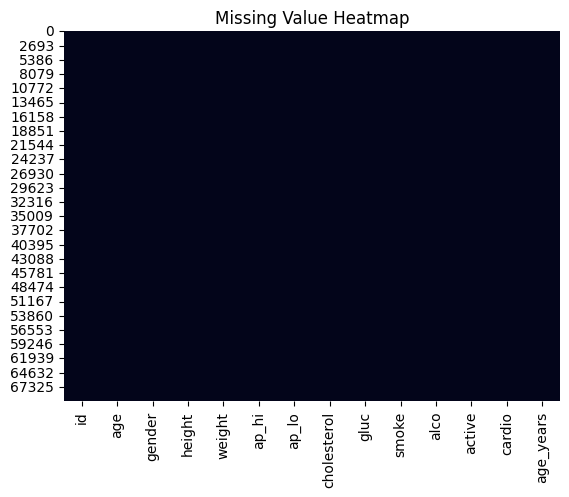

In [7]:
missing_values = df.isnull().sum()

print(missing_values)

sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()

In [8]:
duplicates = df.duplicated().sum()

print("Duplicate Records :", duplicates)

df = df.drop_duplicates()

print("Shape After Removing Duplicates :", df.shape)

Duplicate Records : 0
Shape After Removing Duplicates : (70000, 14)


In [9]:
# Remove ID column

if "id" in df.columns:
    df.drop("id", axis=1, inplace=True)

print(df.head())

     age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0  18393       2     168    62.0    110     80            1     1      0   
1  20228       1     156    85.0    140     90            3     1      0   
2  18857       1     165    64.0    130     70            3     1      0   
3  17623       2     169    82.0    150    100            1     1      0   
4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  age_years  
0     0       1       0         50  
1     0       1       1         55  
2     0       0       1         52  
3     0       1       1         48  
4     0       0       0         48  


In [10]:
# Statistical Summary

print("Statistical Summary")
print("=" * 50)

df.describe()

Statistical Summary


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700,53.303157
std,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003,6.760171
min,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,30.000000
25%,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,48.000000
50%,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,54.000000
75%,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,58.000000
max,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,65.000000


In [11]:
# Set Plot Style

plt.style.use("ggplot")
sns.set(font_scale=1.1)

print("EDA Started Successfully")

EDA Started Successfully


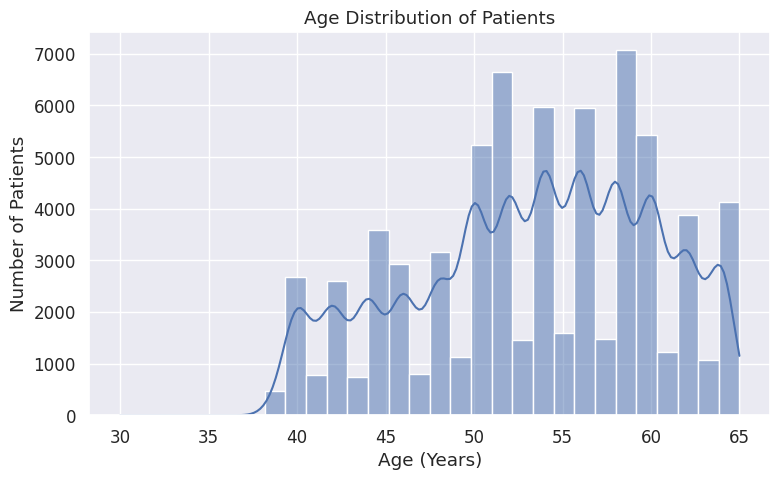

In [12]:
# Create age_years if it does not already exist

if "age_years" not in df.columns:
    df["age_years"] = (df["age"] / 365.25).astype(int)

# Univariate Analysis - Age Distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="age_years",
    bins=30,
    kde=True
)

plt.title("Age Distribution of Patients")
plt.xlabel("Age (Years)")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

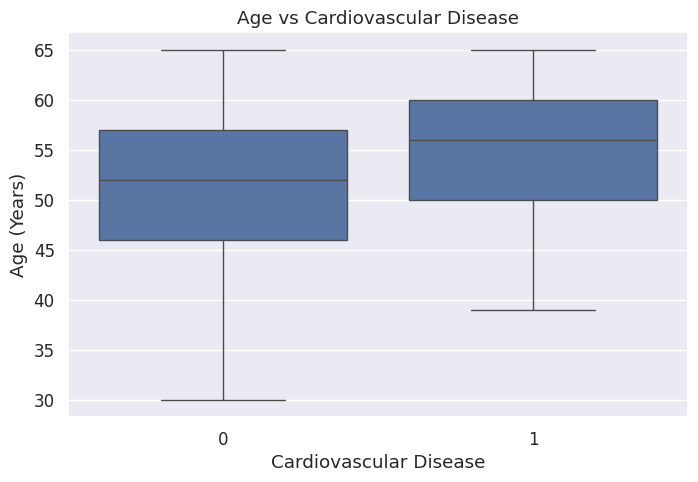

In [13]:
# Bivariate Analysis - Age vs Cardiovascular Disease

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="cardio",
    y="age_years"
)

plt.title("Age vs Cardiovascular Disease")
plt.xlabel("Cardiovascular Disease")
plt.ylabel("Age (Years)")

plt.show()

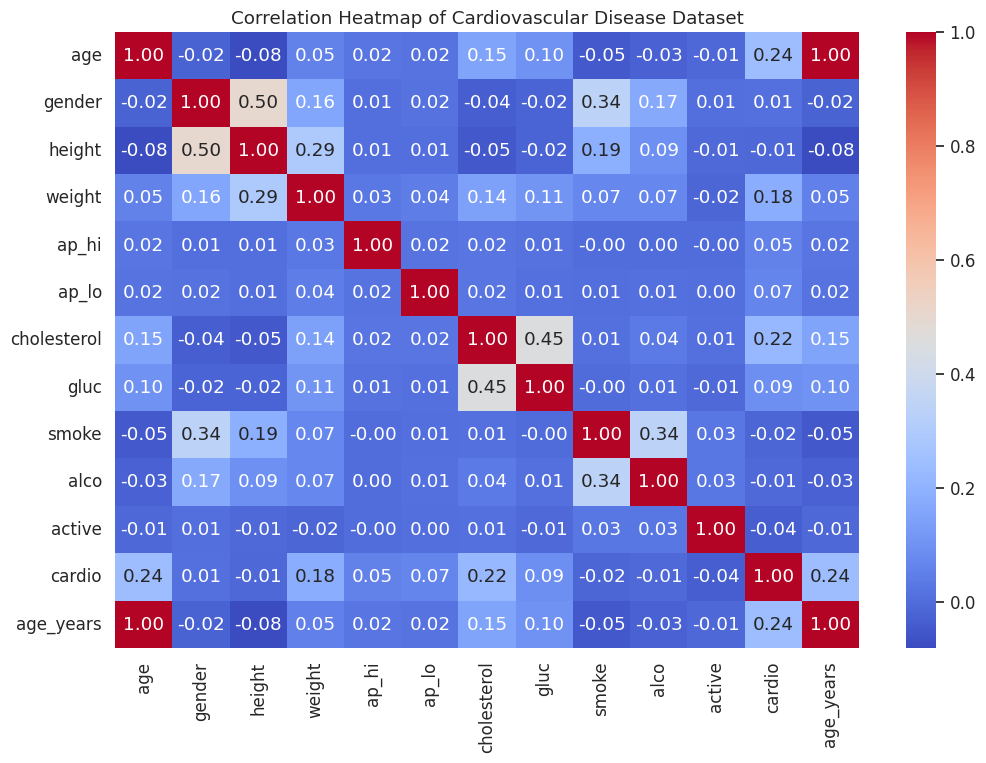

In [14]:
# Multivariate Analysis - Correlation Heatmap

plt.figure(figsize=(12, 8))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Cardiovascular Disease Dataset")

plt.show()

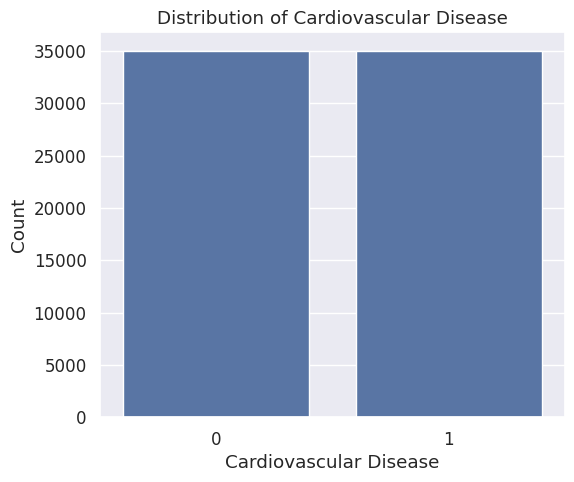

cardio
0    35021
1    34979
Name: count, dtype: int64


In [15]:
plt.figure(figsize=(6,5))

sns.countplot(x="cardio", data=df)

plt.title("Distribution of Cardiovascular Disease")
plt.xlabel("Cardiovascular Disease")
plt.ylabel("Count")

plt.show()

print(df["cardio"].value_counts())

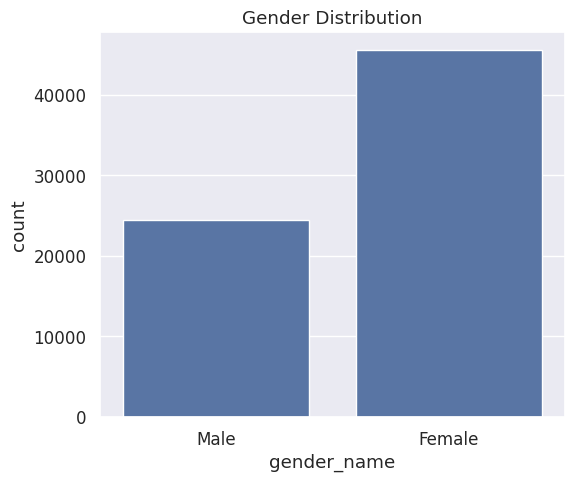

In [16]:
gender_map = {1: "Female", 2: "Male"}

df["gender_name"] = df["gender"].map(gender_map)

plt.figure(figsize=(6,5))

sns.countplot(x="gender_name", data=df)

plt.title("Gender Distribution")

plt.show()

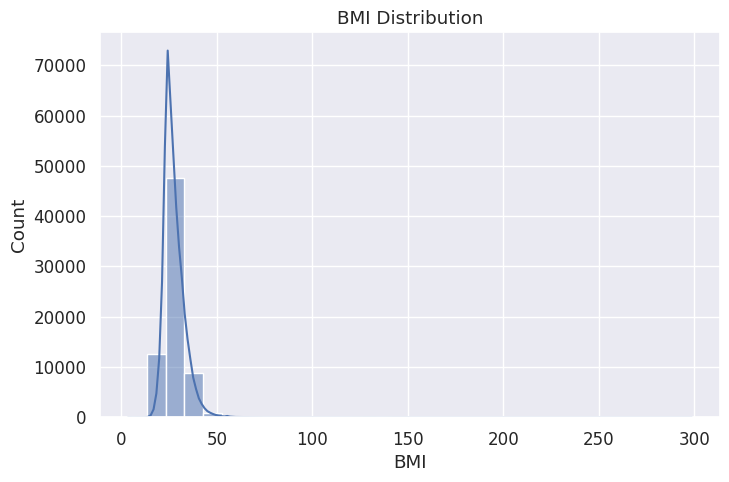

In [17]:
df["height_m"] = df["height"] / 100

df["BMI"] = df["weight"] / (df["height_m"] ** 2)

plt.figure(figsize=(8,5))

sns.histplot(df["BMI"], bins=30, kde=True)

plt.title("BMI Distribution")

plt.show()

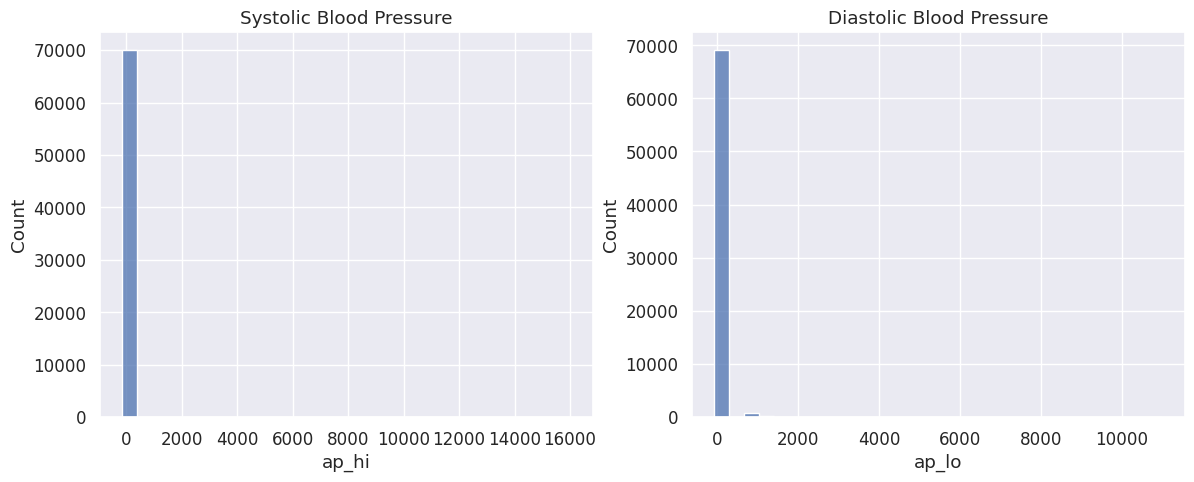

In [18]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

sns.histplot(df["ap_hi"], ax=ax[0], bins=30)

ax[0].set_title("Systolic Blood Pressure")

sns.histplot(df["ap_lo"], ax=ax[1], bins=30)

ax[1].set_title("Diastolic Blood Pressure")

plt.show()

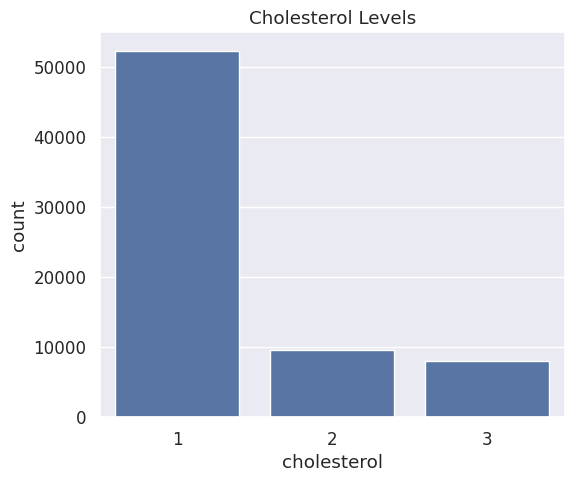

In [19]:
plt.figure(figsize=(6,5))

sns.countplot(x="cholesterol", data=df)

plt.title("Cholesterol Levels")

plt.show()

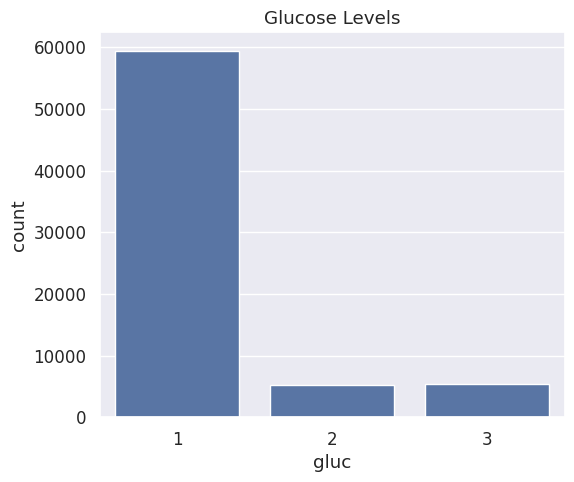

In [20]:
plt.figure(figsize=(6,5))

sns.countplot(x="gluc", data=df)

plt.title("Glucose Levels")

plt.show()

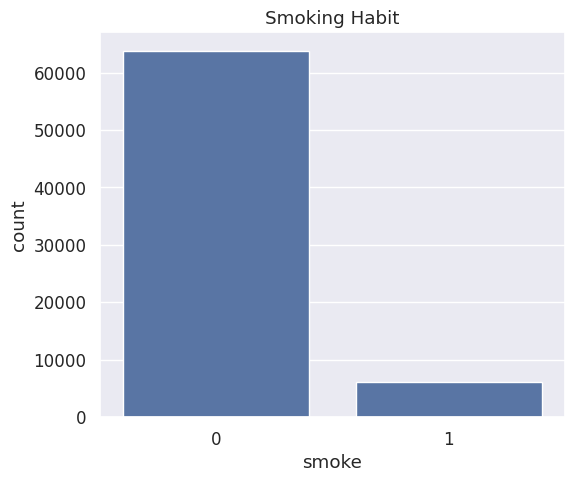

In [21]:
plt.figure(figsize=(6,5))

sns.countplot(x="smoke", data=df)

plt.title("Smoking Habit")

plt.show()

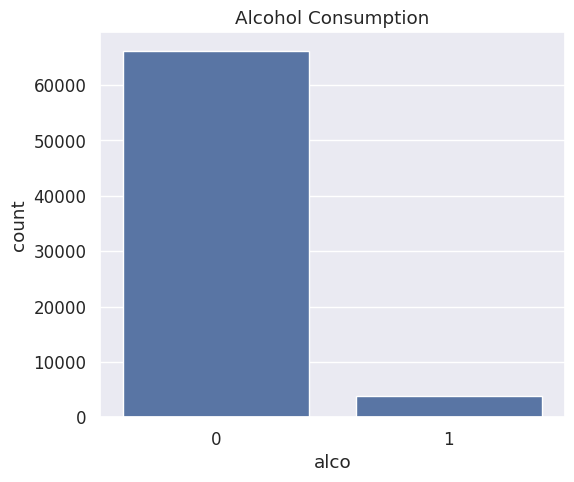

In [22]:
plt.figure(figsize=(6,5))

sns.countplot(x="alco", data=df)

plt.title("Alcohol Consumption")

plt.show()

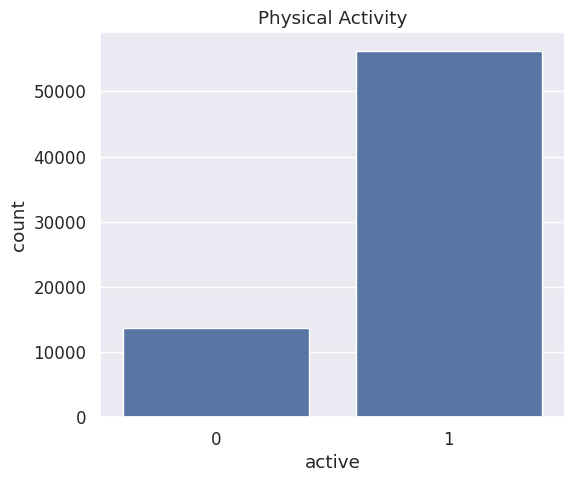

In [23]:
plt.figure(figsize=(6,5))

sns.countplot(x="active", data=df)

plt.title("Physical Activity")

plt.show()

In [24]:
# Create Age Feature (Years)

df["age_years"] = (df["age"] / 365.25).astype(int)

print(df[["age", "age_years"]].head())

     age  age_years
0  18393         50
1  20228         55
2  18857         51
3  17623         48
4  17474         47


In [25]:
# Create BMI Feature

df["height_m"] = df["height"] / 100

df["BMI"] = df["weight"] / (df["height_m"] ** 2)

df[["height", "weight", "BMI"]].head()

,height,weight,BMI
0,168,62.0,21.967120
1,156,85.0,34.927679
2,165,64.0,23.507805
3,169,82.0,28.710479
4,156,56.0,23.011177


In [26]:
# Remove Invalid Blood Pressure

df = df[df["ap_hi"] > 50]
df = df[df["ap_hi"] < 250]

df = df[df["ap_lo"] > 30]
df = df[df["ap_lo"] < 180]

df = df[df["ap_hi"] > df["ap_lo"]]

print("Dataset Shape:", df.shape)

Dataset Shape: (68670, 16)


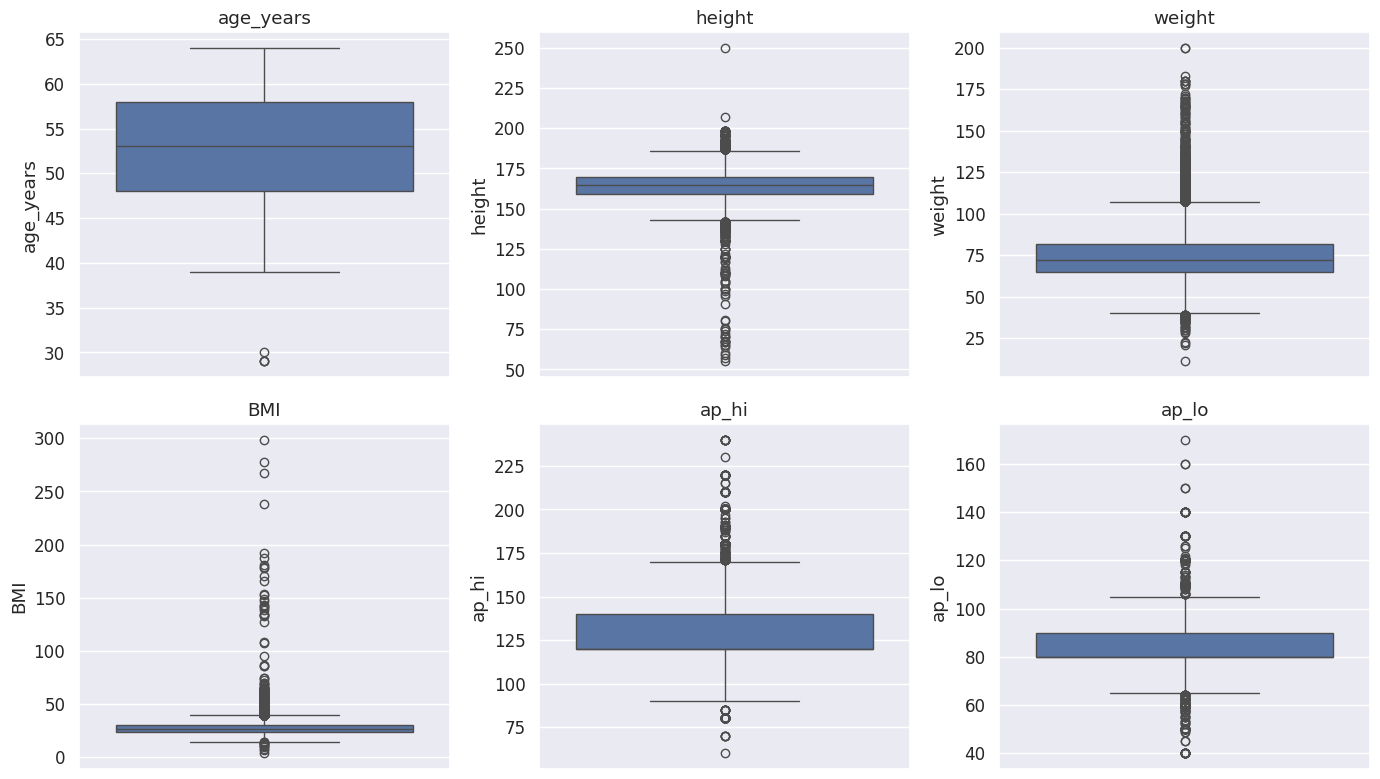

In [27]:
numerical_columns = [
    "age_years",
    "height",
    "weight",
    "BMI",
    "ap_hi",
    "ap_lo"
]

plt.figure(figsize=(14,8))

for i, col in enumerate(numerical_columns):

    plt.subplot(2,3,i+1)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()

plt.show()

In [28]:
df = df[(df["BMI"] > 10) & (df["BMI"] < 60)]

print(df.shape)

(68603, 16)


In [29]:
X = df.drop(columns=["cardio"])

y = df["cardio"]

print("Feature Shape :", X.shape)

print("Target Shape :", y.shape)

Feature Shape : (68603, 15)
Target Shape : (68603,)


In [30]:
# Remove non-numeric columns created for visualization

columns_to_drop = ["gender_name", "height_m"]

for col in columns_to_drop:
    if col in df.columns:
        df.drop(columns=col, inplace=True)

# Features and Target
X = df.drop("cardio", axis=1)
y = df["cardio"]

# Check data types
print(X.dtypes)

age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
age_years        int64
BMI            float64
dtype: object


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (54882, 13)
Testing Data : (13721, 13)


In [32]:
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (54882, 13)
X_test shape : (13721, 13)
y_train shape: (54882,)
y_test shape : (13721,)


In [33]:
# Import Machine Learning Models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [34]:
# Create Empty Dictionary

model_results = {}

In [35]:
lr = LogisticRegression(random_state=42)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_prob = lr.predict_proba(X_test)[:,1]

model_results["Logistic Regression"] = {

    "Accuracy": accuracy_score(y_test, lr_pred),

    "Precision": precision_score(y_test, lr_pred),

    "Recall": recall_score(y_test, lr_pred),

    "F1 Score": f1_score(y_test, lr_pred),

    "ROC AUC": roc_auc_score(y_test, lr_prob)

}

print(model_results["Logistic Regression"])

{'Accuracy': 0.722687850739742, 'Precision': 0.7499581028992793, 'Recall': 0.6592516205067767, 'F1 Score': 0.7016856134849079, 'ROC AUC': np.float64(0.7869526245014895)}


In [36]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_prob = dt.predict_proba(X_test)[:,1]

model_results["Decision Tree"] = {

    "Accuracy": accuracy_score(y_test, dt_pred),

    "Precision": precision_score(y_test, dt_pred),

    "Recall": recall_score(y_test, dt_pred),

    "F1 Score": f1_score(y_test, dt_pred),

    "ROC AUC": roc_auc_score(y_test, dt_prob)

}

print(model_results["Decision Tree"])

{'Accuracy': 0.6410611471467095, 'Precision': 0.6371264537023407, 'Recall': 0.637595757218621, 'F1 Score': 0.6373610190707606, 'ROC AUC': np.float64(0.6410937127745394)}


In [37]:
rf = RandomForestClassifier(

    n_estimators=200,

    random_state=42

)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]

model_results["Random Forest"] = {

    "Accuracy": accuracy_score(y_test, rf_pred),

    "Precision": precision_score(y_test, rf_pred),

    "Recall": recall_score(y_test, rf_pred),

    "F1 Score": f1_score(y_test, rf_pred),

    "ROC AUC": roc_auc_score(y_test, rf_prob)

}

print(model_results["Random Forest"])

{'Accuracy': 0.7160556810728081, 'Precision': 0.7216431637032495, 'Recall': 0.6935769004124926, 'F1 Score': 0.7073317307692307, 'ROC AUC': np.float64(0.7821287678912763)}


In [38]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_prob = knn.predict_proba(X_test)[:,1]

model_results["KNN"] = {

    "Accuracy": accuracy_score(y_test, knn_pred),

    "Precision": precision_score(y_test, knn_pred),

    "Recall": recall_score(y_test, knn_pred),

    "F1 Score": f1_score(y_test, knn_pred),

    "ROC AUC": roc_auc_score(y_test, knn_prob)

}

print(model_results["KNN"])

{'Accuracy': 0.6820202609139275, 'Precision': 0.6885398849323588, 'Recall': 0.652327637006482, 'F1 Score': 0.6699447764581284, 'ROC AUC': np.float64(0.7286642411443618)}


In [39]:
nb = GaussianNB()

nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

nb_prob = nb.predict_proba(X_test)[:,1]

model_results["Naive Bayes"] = {

    "Accuracy": accuracy_score(y_test, nb_pred),

    "Precision": precision_score(y_test, nb_pred),

    "Recall": recall_score(y_test, nb_pred),

    "F1 Score": f1_score(y_test, nb_pred),

    "ROC AUC": roc_auc_score(y_test, nb_prob)

}

print(model_results["Naive Bayes"])

{'Accuracy': 0.7130675606734203, 'Precision': 0.7519886865829946, 'Recall': 0.626694166175604, 'F1 Score': 0.6836480514262756, 'ROC AUC': np.float64(0.7786094359166841)}


In [40]:
results_df = pd.DataFrame(model_results).T

results_df = results_df.round(4)

results_df.sort_values(by="Accuracy", ascending=False)

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Logistic Regression,0.7227,0.7500,0.6593,0.7017,0.7870
Random Forest,0.7161,0.7216,0.6936,0.7073,0.7821
Naive Bayes,0.7131,0.7520,0.6267,0.6836,0.7786
KNN,0.6820,0.6885,0.6523,0.6699,0.7287
Decision Tree,0.6411,0.6371,0.6376,0.6374,0.6411


In [41]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Small parameter grid for faster execution
rf_params = {
    "n_estimators": [100, 150],
    "max_depth": [10, 20],
    "min_samples_split": [2]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=rf_params,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:")
print(rf_grid.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(round(rf_grid.best_score_, 4))

Best Parameters:
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 150}

Best Cross-Validation Accuracy:
0.7339


In [42]:
best_rf = rf_grid.best_estimator_

best_rf_pred = best_rf.predict(X_test)
best_rf_prob = best_rf.predict_proba(X_test)[:, 1]

print("Best Random Forest Model Ready")

Best Random Forest Model Ready


In [43]:
from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "KNN": knn,
    "Naive Bayes": nb
}

cv_scores = {}

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=3,
        scoring="accuracy",
        n_jobs=-1
    )

    cv_scores[name] = scores.mean()

    print(f"{name}: {scores.mean():.4f}")

Logistic Regression: 0.7169
Decision Tree: 0.6280
Random Forest: 0.7137
KNN: 0.6786
Naive Bayes: 0.7071


In [44]:
cv_df = pd.DataFrame(
    list(cv_scores.items()),
    columns=["Model", "CV Accuracy"]
)

cv_df = cv_df.sort_values(
    "CV Accuracy",
    ascending=False
).reset_index(drop=True)

cv_df

,Model,CV Accuracy
0,Logistic Regression,0.716902
1,Random Forest,0.713677
2,Naive Bayes,0.707099
3,KNN,0.678620
4,Decision Tree,0.628002


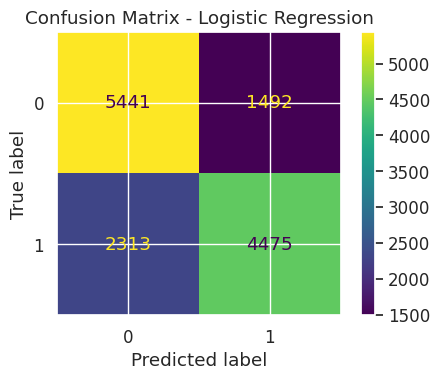

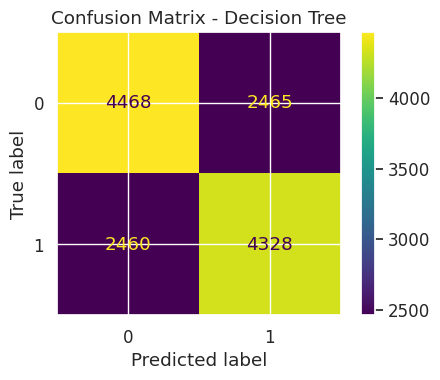

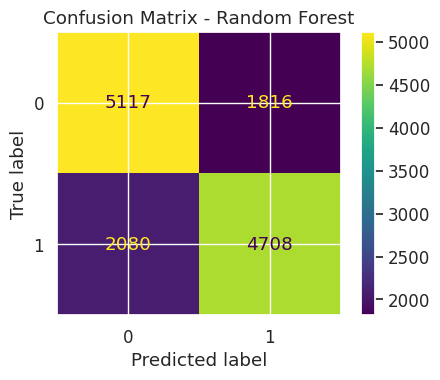

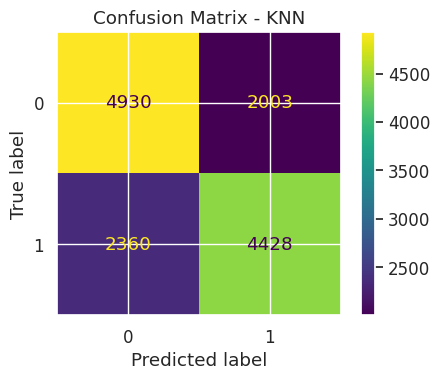

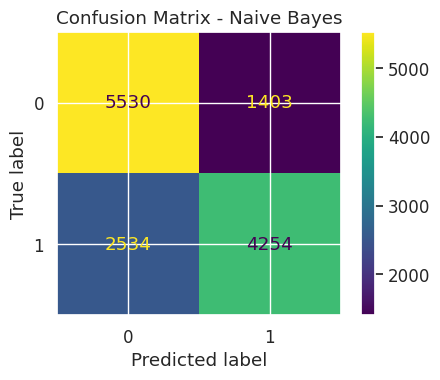

In [45]:
from sklearn.metrics import ConfusionMatrixDisplay

predictions = {
    "Logistic Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "KNN": knn_pred,
    "Naive Bayes": nb_pred
}

for name, pred in predictions.items():

    fig, ax = plt.subplots(figsize=(5, 4))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        pred,
        ax=ax
    )

    ax.set_title(f"Confusion Matrix - {name}")
    plt.tight_layout()
    plt.show()

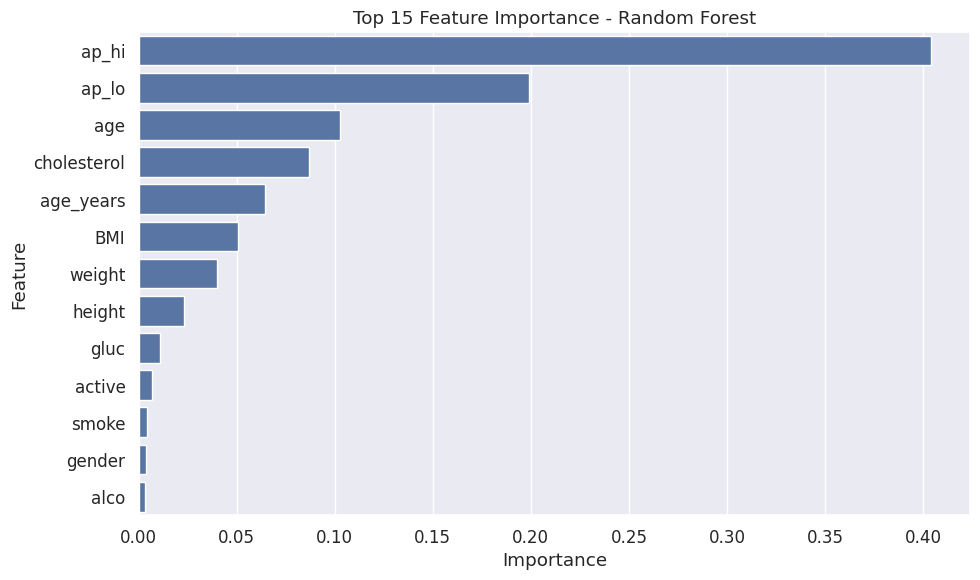

,Feature,Importance
4,ap_hi,0.403924
5,ap_lo,0.199257
0,age,0.102805
6,cholesterol,0.086660
11,age_years,0.064484
12,BMI,0.050920
3,weight,0.040012
2,height,0.023077
7,gluc,0.010671
10,active,0.006754


In [46]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importance - Random Forest")
plt.tight_layout()
plt.show()

importance_df.head(15)

In [47]:
from sklearn.metrics import classification_report

print("Classification Report - Optimized Random Forest")
print("=" * 55)

print(
    classification_report(
        y_test,
        best_rf_pred
    )
)

Classification Report - Optimized Random Forest
              precision    recall  f1-score   support

           0       0.72      0.78      0.75      6933
           1       0.76      0.69      0.72      6788

    accuracy                           0.74     13721
   macro avg       0.74      0.74      0.74     13721
weighted avg       0.74      0.74      0.74     13721



In [48]:
best_rf_accuracy = accuracy_score(y_test, best_rf_pred)
best_rf_precision = precision_score(y_test, best_rf_pred)
best_rf_recall = recall_score(y_test, best_rf_pred)
best_rf_f1 = f1_score(y_test, best_rf_pred)
best_rf_auc = roc_auc_score(y_test, best_rf_prob)

final_rf_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Score": [
        best_rf_accuracy,
        best_rf_precision,
        best_rf_recall,
        best_rf_f1,
        best_rf_auc
    ]
})

final_rf_metrics["Score"] = final_rf_metrics["Score"].round(4)

final_rf_metrics

,Metric,Score
0,Accuracy,0.7362
1,Precision,0.7574
2,Recall,0.6868
3,F1-Score,0.7204
4,ROC-AUC,0.8055


In [49]:
# Create Final Model Comparison Table

final_results = pd.DataFrame(model_results).T

final_results = final_results[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]
]

final_results = final_results.sort_values(
    by="F1 Score",
    ascending=False
)

final_results.round(4)

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Random Forest,0.7161,0.7216,0.6936,0.7073,0.7821
Logistic Regression,0.7227,0.7500,0.6593,0.7017,0.7870
Naive Bayes,0.7131,0.7520,0.6267,0.6836,0.7786
KNN,0.6820,0.6885,0.6523,0.6699,0.7287
Decision Tree,0.6411,0.6371,0.6376,0.6374,0.6411


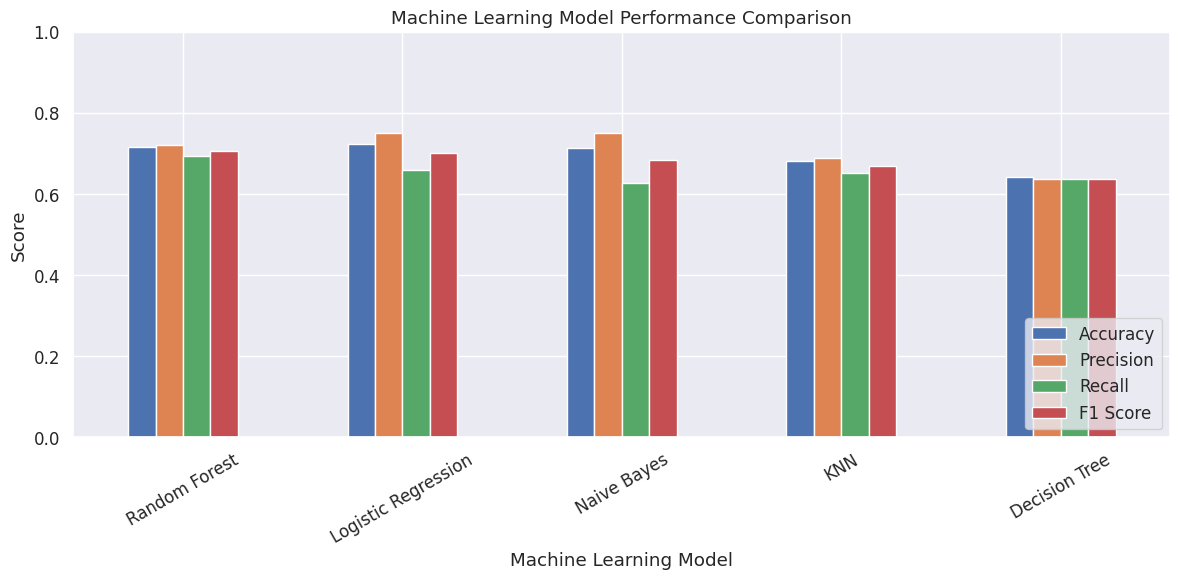

In [50]:
# Model Performance Comparison

final_results[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Machine Learning Model Performance Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [51]:
# Select Best Model

best_model_name = final_results["F1 Score"].idxmax()

best_model_score = final_results.loc[
    best_model_name,
    "F1 Score"
]

print("Best Model:", best_model_name)
print("Best F1-Score:", round(best_model_score, 4))

Best Model: Random Forest
Best F1-Score: 0.7073


In [52]:
# Display Best Model Performance

best_model_metrics = final_results.loc[
    best_model_name
]

print("Best Model Performance")
print("=" * 40)

for metric, score in best_model_metrics.items():
    print(f"{metric}: {score:.4f}")

Best Model Performance
Accuracy: 0.7161
Precision: 0.7216
Recall: 0.6936
F1 Score: 0.7073
ROC AUC: 0.7821


In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

# Test prediction
y_pred = rf_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", round(accuracy * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Random Forest Accuracy: 71.45 %

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.74      0.72      6933
           1       0.72      0.69      0.71      6788

    accuracy                           0.71     13721
   macro avg       0.71      0.71      0.71     13721
weighted avg       0.71      0.71      0.71     13721



In [54]:
# 1. Features - age removed, age_years used
features = [
    'age_years',
    'gender',
    'height',
    'weight',
    'ap_hi',
    'ap_lo',
    'cholesterol',
    'gluc',
    'smoke',
    'alco',
    'active',
    'BMI'
]

# 2. X and y
X = df[features]
y = df['cardio']

print("Number of features:", X.shape[1])
print("Features:", X.columns.tolist())


# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# 4. CREATE NEW Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


# 5. TRAIN NEW MODEL
rf_model.fit(X_train, y_train)


# 6. CHECK MODEL
print("Model expects:", rf_model.n_features_in_, "features")
print("Model features:", rf_model.feature_names_in_)

Number of features: 12
Features: ['age_years', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'BMI']
Model expects: 12 features
Model features: ['age_years' 'gender' 'height' 'weight' 'ap_hi' 'ap_lo' 'cholesterol'
 'gluc' 'smoke' 'alco' 'active' 'BMI']


In [55]:
def predict_cardiovascular_risk(
    age_years,
    gender,
    height,
    weight,
    ap_hi,
    ap_lo,
    cholesterol,
    gluc,
    smoke,
    alco,
    active
):
    BMI = weight / ((height / 100) ** 2)

    input_data = pd.DataFrame([[
        age_years,
        gender,
        height,
        weight,
        ap_hi,
        ap_lo,
        cholesterol,
        gluc,
        smoke,
        alco,
        active,
        BMI
    ]], columns=[
        'age_years',
        'gender',
        'height',
        'weight',
        'ap_hi',
        'ap_lo',
        'cholesterol',
        'gluc',
        'smoke',
        'alco',
        'active',
        'BMI'
    ])

    prediction = rf_model.predict(input_data)[0]
    probability = rf_model.predict_proba(input_data)[0][1]

    result = "❤️High Risk" if prediction == 1 else "💚 Low Risk"

    return result, probability

In [56]:
result, probability = predict_cardiovascular_risk(
    age_years=55,
    gender=1,
    height=170,
    weight=75,
    ap_hi=140,
    ap_lo=90,
    cholesterol=2,
    gluc=1,
    smoke=0,
    alco=0,
    active=1
)

print("\n" + "=" * 50)
print("❤️  CARDIOVASCULAR RISK PREDICTION  ❤️")
print("=" * 50)

if "High Risk" in result:
    print("❤️  Prediction          :", result)
    print("⚠️  Risk Status         : High Risk Detected")
else:
    print("💚  Prediction          :", result)
    print("💚  Risk Status         : Low Risk Detected")

print("📊 Disease Probability  :", round(probability * 100, 2), "%")
print("=" * 50)


❤️  CARDIOVASCULAR RISK PREDICTION  ❤️
❤️  Prediction          : ❤️High Risk
⚠️  Risk Status         : High Risk Detected
📊 Disease Probability  : 66.0 %


In [57]:
result, probability = predict_cardiovascular_risk(
    age_years=35,
    gender=1,
    height=175,
    weight=65,
    ap_hi=115,
    ap_lo=75,
    cholesterol=1,
    gluc=1,
    smoke=0,
    alco=0,
    active=1
)

print("Prediction:", result)
print("Disease Probability:", round(probability * 100, 2), "%")

Prediction: 💚 Low Risk
Disease Probability: 9.0 %
